# Description

Notebook to create a sin based dataset

In [31]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('Tesis')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
CURRENT_DIR = os.path.join(CURRENT_DIR, 'noise_reduction')
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [32]:
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
from IPython.display import display, clear_output
from tqdm import tqdm
import math

# Locals
from utils import *
from dataset import BioFuelDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

In [33]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [35]:
def sin_function(x):
    """
    Function that takes in a value x and returns its sin.
    The values are scaled to be between 0 and 1.

    Args:
        x (float): value to be transformed.

    Returns:
        float: value of sin(x) scaled to be between 0 and 1.
    """

    return (1 + np.sin(np.pi * x))/2


def polinomial_function(x):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6

def polinomial_function_2variable(x0, x1):
    """
    Function that takes in two values x0 and x1 and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """
    # return np.sin(np.sqrt(x0**2 + x1**2))
    return x0**2 + x1**2


def generate_data(num_points, degree, noise=0.1):
    x = np.random.uniform(-1, 1, num_points)
    y_true = np.polyval(np.random.rand(degree + 1), x)
    y_noisy = y_true #+ noise * np.random.randn(num_points)
    return x, y_noisy


def add_gaussian_noise(df, columns, mean=0, std=0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df


def distancia_ortogonal(x0, y0, m, b):
    distancias = []
    for i in range(len(x0)):
        # Coordenadas del pie de la perpendicular
        x1 = (x0[i] + m * y0[i] - m * b) / (m**2 + 1)
        y1 = m * x1 + b
        
        # Distancia entre dos puntos en el plano
        distancia = math.sqrt((x1 - x0[i])**2 + (y1 - y0[i])**2)
        
        distancias.append(distancia)
    
    return distancias


In [36]:
X_train = np.array([np.random.normal(size=3000), np.random.normal(size=3000)]).T
X_train = pd.DataFrame(X_train, columns=['x0', 'x1'])
y_train = polinomial_function_2variable(X_train['x0'], X_train['x1'])

df_train = pd.concat([X_train, pd.DataFrame(y_train, columns=['y'])], axis=1)

Text(0.5, 0, 'y')

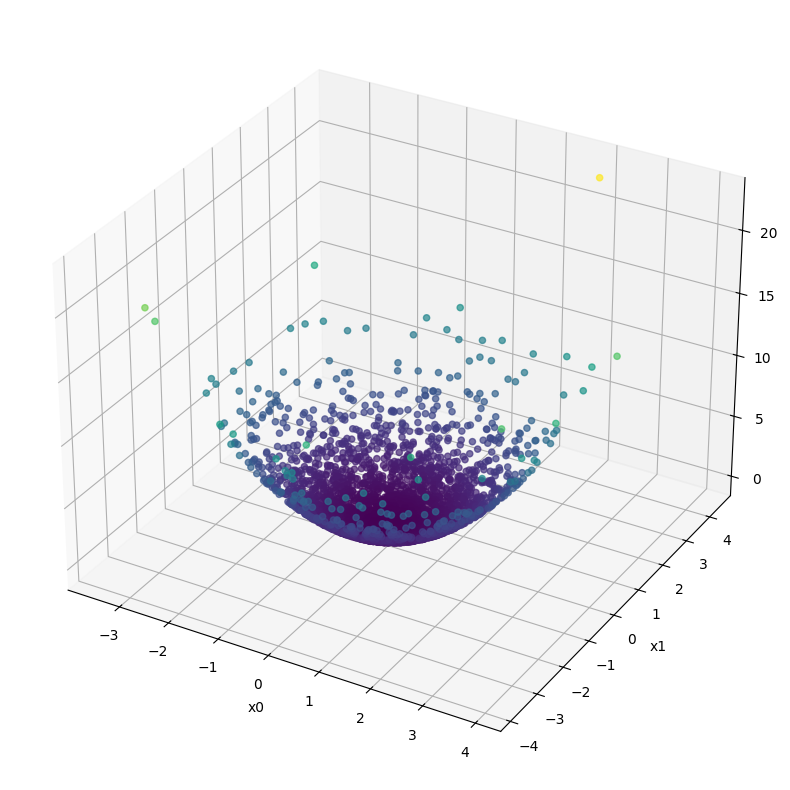

In [37]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_train['x0'], df_train['x1'], df_train['y'], marker='o', c=df_train['y'], cmap='viridis', alpha=0.7)

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')

In [38]:
df_val = df_train.copy()
df_test = df_train.copy()
df_noisy = df_train.copy()

In [39]:
scaler = MinMaxScaler()
df_noisy = pd.DataFrame(scaler.fit_transform(df_noisy))
df_noisy.columns = ['x0', 'x1', 'y']

In [40]:
sigma = 0.04
df_noisy = add_gaussian_noise(
        df=df_noisy.copy(),
        columns=[x for x in df_train.columns],
        mean=0,
        std=sigma
)

Text(0.5, 0, 'y')

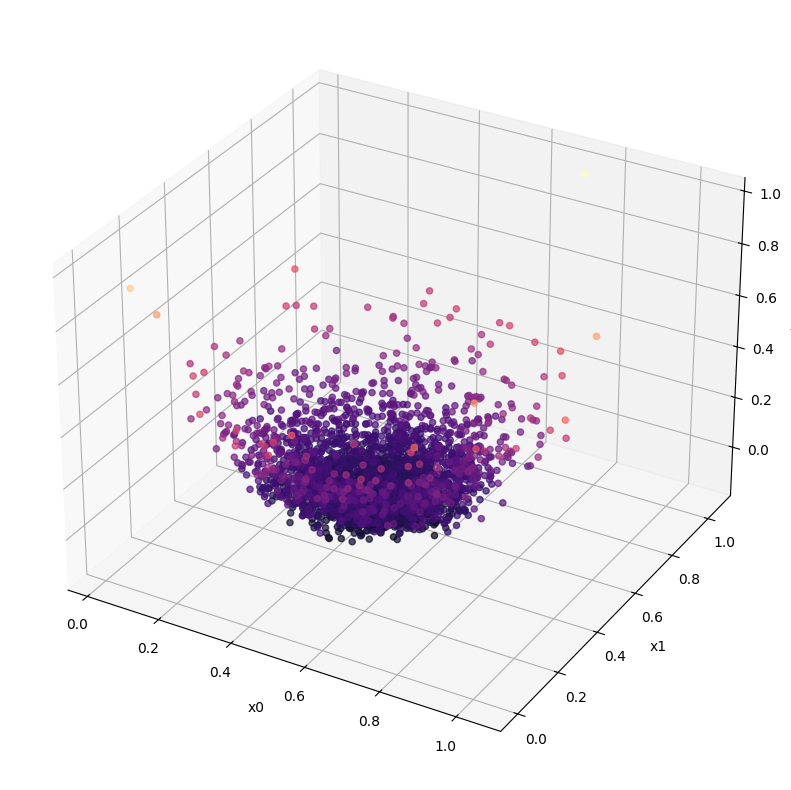

In [41]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_noisy['x0'], df_noisy['x1'], df_noisy['y'], marker='o', c=df_noisy['y'], cmap='magma', alpha=0.7)

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')

In [42]:
df_train = pd.DataFrame(scaler.transform(df_train))
df_train.columns = ['x0', 'x1', 'y']
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,3000.0,0.474441,0.133507,0.0,0.386839,0.475006,0.562114,1.0
x1,3000.0,0.463917,0.126093,0.0,0.381841,0.463152,0.547637,1.0
y,3000.0,0.090263,0.094800,0.0,0.024358,0.061722,0.122883,1.0


In [43]:
df_val = pd.DataFrame(scaler.transform(df_val))
df_val.columns = ['x0', 'x1', 'y']
df_val.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,3000.0,0.474441,0.133507,0.0,0.386839,0.475006,0.562114,1.0
x1,3000.0,0.463917,0.126093,0.0,0.381841,0.463152,0.547637,1.0
y,3000.0,0.090263,0.094800,0.0,0.024358,0.061722,0.122883,1.0


In [44]:
df_test = pd.DataFrame(scaler.transform(df_test))
df_test.columns = ['x0', 'x1', 'y']
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,3000.0,0.474441,0.133507,0.0,0.386839,0.475006,0.562114,1.0
x1,3000.0,0.463917,0.126093,0.0,0.381841,0.463152,0.547637,1.0
y,3000.0,0.090263,0.094800,0.0,0.024358,0.061722,0.122883,1.0


In [45]:
# _X_train, X_test, _y_train, y_test = train_test_split(
#     df_noisy['X'], df_noisy['y'], 
#     test_size=0.2, 
#     shuffle=False
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     _X_train, _y_train, 
#     test_size=0.15, 
#     shuffle=False
# )

# # unsorted_train_indexes = X_train.index.tolist()
# # random.shuffle(unsorted_train_indexes)
# # unsorted_val_indexes = X_val.index.tolist()
# # random.shuffle(unsorted_val_indexes)
# # unsorted_test_indexes = X_test.index.tolist()
# # random.shuffle(unsorted_test_indexes)

# # X_train = X_train[unsorted_train_indexes]
# # y_train = y_train[unsorted_train_indexes]
# # X_val = X_val[unsorted_val_indexes]
# # y_val = y_val[unsorted_val_indexes]
# # X_test = X_test[unsorted_test_indexes]
# # y_test = y_test[unsorted_test_indexes]

# Transform the data into a tensor
bio_dataset_train = BioFuelDataset(
    input_df=df_noisy[['x0', 'x1']],
    target_df=df_noisy[['y']]
)
# Transform the data into a tensor
bio_dataset_val = BioFuelDataset(
    input_df=df_noisy[['x0', 'x1']],
    target_df=df_val[['y']]
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(bio_dataset_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(bio_dataset_val, batch_size=batch_size, shuffle=True, num_workers=0)

In [46]:
model = GridFullyDenseNN(
    n_layers=2,
    hidden_layers=[
        (2, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.ReLU(),
        nn.Identity(),
    ],
    want_dropout=[
        False,
        False,
    ],
    want_linear=[
        True,
        True,
    ],
    want_activation=[
        True,
        False,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=2, out_features=1024, bias=True)
    (activation_0): ReLU()
    (linear_1): Linear(in_features=1024, out_features=1, bias=True)
  )
)

In [47]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_sin_noise_{sigma}_2variables'),
)

In [48]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:   6%| | 32/500 [00:31<07:42,  1.01epoch/s, Train loss: 0.003059593702976902 - Val loss: 0.001

Training stopped as validation loss did not improve for 15 epochs.


In [49]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_sin_noise_{sigma}_2variables.pth')))

In [50]:
y_pred_test = model(torch.tensor(df_test[['x0', 'x1']].values.reshape(-1, 2)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [51]:
y_pred_val = model(torch.tensor(df_val[['x0', 'x1']].values.reshape(-1, 2)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [52]:
y_pred_train = model(torch.tensor(df_noisy[['x0', 'x1']].values.reshape(-1, 2)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [53]:
mae = mean_absolute_error(df_test['y'].values, y_pred_test)
mse = mean_squared_error(df_test['y'].values, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((df_test['y'].values - y_pred_test) / df_test['y'].values)) * 100
r_squared = r2_score(df_test['y'].values, y_pred_test)
print("MAE: ", mae)
print("MAPE: ", mape)
print("RMSE: ", rmse)
print("MSE: ", mse)
print("R-squared: ", r_squared)

MAE:  0.013026049115389161
MAPE:  inf
RMSE:  0.020032490530875073
MSE:  0.0004013006768695995
R-squared:  0.9553313882088863


/tmp/ipykernel_2186776/1156229740.py:4: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((df_test['y'].values - y_pred_test) / df_test['y'].values)) * 100


Text(0.5, 0, 'y')

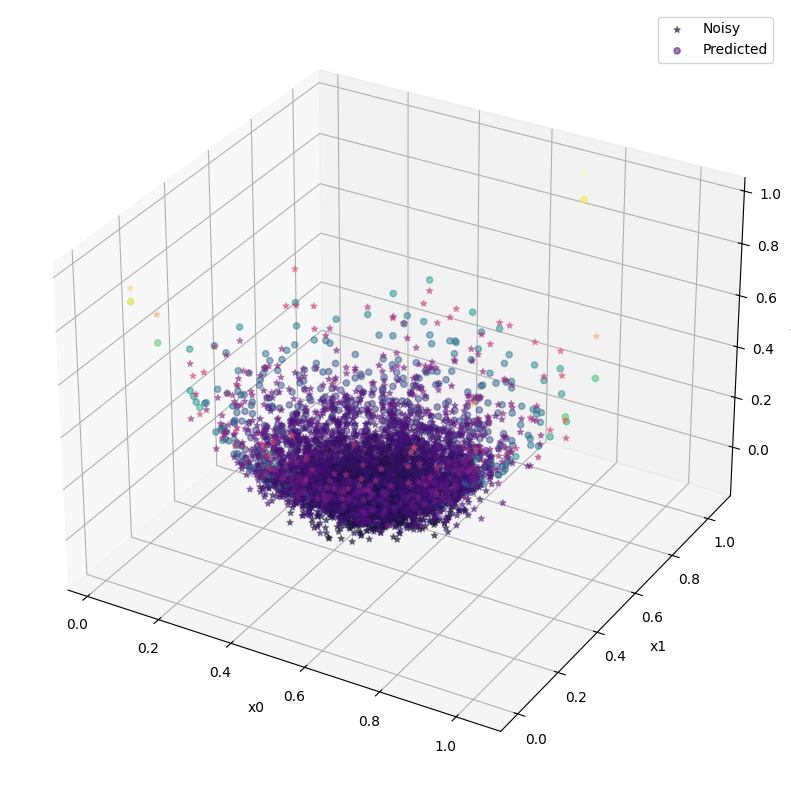

In [54]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_noisy['x0'], df_noisy['x1'], df_noisy['y'], marker='*', c=df_noisy['y'], cmap='magma', alpha=0.5)
ax.scatter(df_noisy['x0'], df_noisy['x1'], y_pred_train, marker='o', c=y_pred_train, cmap='viridis', alpha=0.5)
ax.legend(['Noisy', 'Predicted'])

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')

# Gradients to reduce noise

In [55]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy[['x0', 'x1']].values, df_noisy['y'].values.reshape(-1, 1))

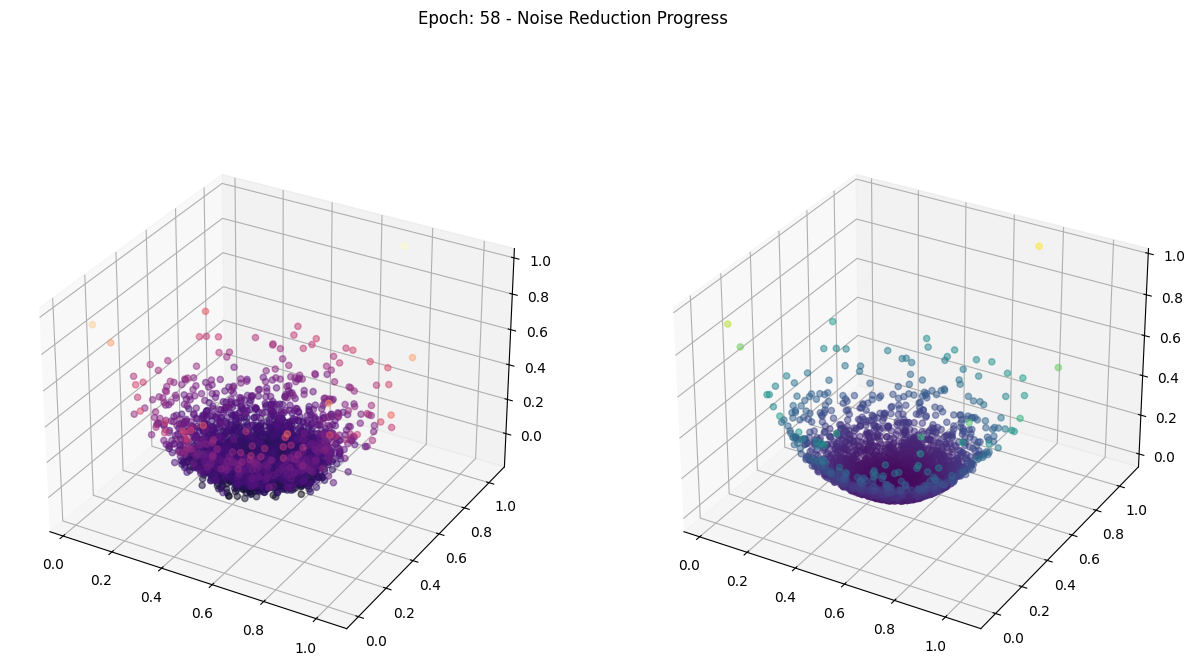

In [56]:
df_no_noise[['x0', 'x1']], df_no_noise['y'] = dlnr.transform(
                                                nrr=0.05,
                                                nr_threshold=0.01,
                                                max_epochs=100,
                                                plot_progress=True
                                            )

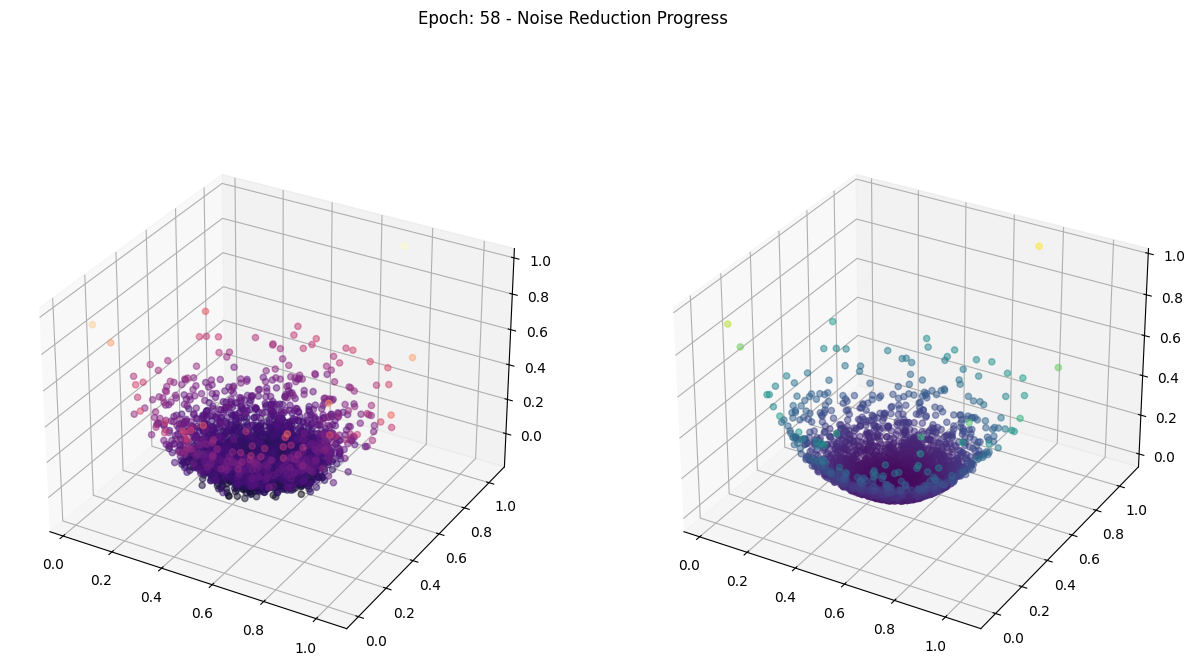

In [57]:
df_no_noise[['x0', 'x1']], df_no_noise['y'] = dlnr.fit_transform(
    X=df_noisy[['x0', 'x1']].values,
    y=df_noisy['y'].values.reshape(-1, 1),
    nrr=0.05,
    nr_threshold=0.01,
    max_epochs=100,
    plot_progress=True
)

In [58]:
y_polinom_noise = polinomial_function_2variable(df_noisy['x0'], df_noisy['x1'])
y_polinom_denoise = polinomial_function_2variable(df_no_noise['x0'], df_no_noise['x1'])
noisy_error = np.sqrt(criterion(torch.tensor(y_polinom_noise), torch.tensor(df_noisy['y'].values)))
denoised_error = np.sqrt(criterion(torch.tensor(y_polinom_denoise), torch.tensor(df_no_noise['y'].values)))
display(noisy_error.item())
display(denoised_error.item())
display(denoised_error.item() < noisy_error.item())

0.43432843259712606

0.4305162885392782

True

In [59]:
df_noisy = pd.DataFrame(scaler.inverse_transform(df_noisy))
df_noisy.columns = ['x0', 'x1', 'y']
df_no_noise = pd.DataFrame(scaler.inverse_transform(df_no_noise))
df_no_noise.columns = ['x0', 'x1', 'y']

In [60]:
y_polinom_noise = polinomial_function_2variable(df_noisy['x0'], df_noisy['x1'])
y_polinom_denoise = polinomial_function_2variable(df_no_noise['x0'], df_no_noise['x1'])
noisy_error = np.sqrt(criterion(torch.tensor(y_polinom_noise), torch.tensor(df_noisy['y'].values)))
denoised_error = np.sqrt(criterion(torch.tensor(y_polinom_denoise), torch.tensor(df_no_noise['y'].values)))
display(noisy_error.item())
display(denoised_error.item())
display(denoised_error.item() < noisy_error.item())

1.2817793737279712

0.5555872141891373

True